# Modelling Overall Performance of FIFA 2019 Forward Players
### A Multiple Linear Regression Analysis

---

## 1. Objective

This analysis aims to **model the general performance and value of football players** who play in forward positions (`Overall`) using a combination of physical characteristics and mentality scores.

More specifically, the goal is to understand **which mentality characteristics most influence the overall rating** of a forward player in FIFA 2019.

### Dataset
The dataset (`data.csv`) comes from [Kaggle – FIFA19 Complete Player Dataset](https://www.kaggle.com/karangadiya/fifa19) and contains detailed attributes for each player registered in the FIFA 2019 edition:
- **18,159 entries** (male players)
- Variables relating to origin, club, physical attributes, and mental/physical skills

### Scope
Only **forward players** were selected (positions: ST, RS, LS, CF, RF, LF), resulting in **2,727 entries**. After removing rows with missing values across explanatory variables, the final dataset contains **2,667 entries** with **10 predictors**.

### Variables

| # | Variable | Description |
|---|----------|-------------|
| 1 | `Overall` | General performance quality and player value (1–99) — **response variable** |
| 2 | `Age` | Player age |
| 3 | `Height` | Player height (cm), categorised into 3 levels |
| 4 | `Weight` | Player weight (kg) |
| 5 | `PreferredFoot` | Dominant foot: 0 = Left, 1 = Right |
| 6 | `Aggression` | Aggression level (pushing, pulling, confrontation) (1–99) |
| 7 | `Interceptions` | Ability to intercept the ball from the opposing team (1–99) |
| 8 | `Positioning` | Ability to position to receive the ball or score goals (1–99) |
| 9 | `Vision` | Ability to mentally visualise the entire team's game (1–99) |
| 10 | `Penalties` | Ability to score penalty goals (1–99) |
| 11 | `Composure` | Ability to control emotions and remain calm during play (1–99) |

\
> **Note on `Height` categorisation:** To meet the study's requirements for a multi-category variable, `Height` was discretised into three levels:
> - **Baixo (Low):** Height ≤ 160 cm  
> - **Médio (Medium):** 160 cm < Height < 185 cm  
> - **Alto (High):** Height ≥ 185 cm

---
## Setup — Load Libraries

In [2]:
library(readr)
library(stringr)
library(car)
library(ggstatsplot)
library(ggcorrplot)
library(QuantPsyc)

---
## 2. Data Loading, Cleaning & Preparation

### 2.1 Load and Filter Forward Players

We begin by loading the full FIFA 2019 dataset and subsetting to forward positions only. The following position codes are included: **ST** (centre striker), **RS** (right striker), **LS** (left striker), **CF** (centre forward), **RF** (right forward), and **LF** (left forward).

From the full 18,159-player dataset, this filter yields **2,727 observations** with 11 variables of interest.

In [ ]:
data <- read_csv("data/data.csv")

dim(data) # 18.207 89

New names:
• `` -> `...1`
Rows: 18207 Columns: 89
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (45): Name, Photo, Nationality, Flag, Club, Club Logo, Value, Wage, Pref...
dbl (44): ...1, ID, Age, Overall, Potential, Special, International Reputati...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 18207    89

In [25]:
# Select forward players and relevant variables
forward_positions <- c("ST", "RS", "LS", "CF", "RF", "LF")

fifa19_forward_pos <- data[
  data$Position %in% forward_positions,
  c("Overall", "Age", "Height", "Weight", "Preferred Foot",
    "Aggression", "Interceptions", "Positioning", "Vision", "Penalties", "Composure")
]

cat("Dimensions before cleaning:", dim(fifa19_forward_pos), "\n") # 2667 11 

Dimensions before cleaning: 2667 11 


In [26]:
head(fifa19_forward_pos)

Overall,Age,Height,Weight,Preferred Foot,Aggression,Interceptions,Positioning,Vision,Penalties,Composure
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
94,31,5'7,159lbs,Left,48,22,94,94,75,96
94,33,6'2,183lbs,Right,63,29,95,82,85,95
91,27,5'8,163lbs,Right,54,41,87,89,86,91
91,31,6'0,190lbs,Right,87,41,92,84,85,85
90,29,6'0,176lbs,Right,80,39,91,77,88,86
89,24,5'10,165lbs,Left,48,32,84,87,86,84


In [27]:
dim(fifa19_forward_pos)

[1] 2667   11

In [20]:
# just to confirm that we have only forward positions in our dataset (include "Position" in the subset of variables)
# unique(fifa19_forward_pos$Position) 

Let's investigate the variables (target and explanatory variables). 

**Variable types:** Overall, Age, Aggression, Interceptions, Positioning, Vision, Penalties, and Composure are numeric, while Height, Weight, and Preferred Foot are character variables and will need to be transformed before modeling.

In [30]:
sapply(nfifa19_forward_pos, class)

Overall            Age         Height         Weight Preferred Foot 
     "numeric"      "numeric"    "character"    "character"    "character" 
    Aggression  Interceptions    Positioning         Vision      Penalties 
     "numeric"      "numeric"      "numeric"      "numeric"      "numeric" 
     Composure 
     "numeric"

In [31]:
summary(nfifa19_forward_pos)

    Overall           Age           Height             Weight         
 Min.   :47.00   Min.   :16.00   Length:2667        Length:2667       
 1st Qu.:62.00   1st Qu.:21.00   Class :character   Class :character  
 Median :66.00   Median :25.00   Mode  :character   Mode  :character  
 Mean   :66.29   Mean   :24.98                                        
 3rd Qu.:71.00   3rd Qu.:28.00                                        
 Max.   :94.00   Max.   :39.00                                        
 Preferred Foot       Aggression    Interceptions    Positioning   
 Length:2667        Min.   :17.00   Min.   :10.00   Min.   :35.00  
 Class :character   1st Qu.:39.00   1st Qu.:18.00   1st Qu.:59.00  
 Mode  :character   Median :53.00   Median :24.00   Median :66.00  
                    Mean   :52.63   Mean   :26.79   Mean   :65.79  
                    3rd Qu.:65.00   3rd Qu.:34.00   3rd Qu.:72.00  
                    Max.   :94.00   Max.   :73.00   Max.   :95.00  
     Vision        Penaltie

### 2.2 Handle Missing Values

Inspection reveals **0 rows** with missing values. 

In [28]:
colSums(is.na(nfifa19_forward_pos))

Overall            Age         Height         Weight Preferred Foot 
             0              0              0              0              0 
    Aggression  Interceptions    Positioning         Vision      Penalties 
             0              0              0              0              0 
     Composure 
             0

### 2.3 Variable Transformations

The raw dataset stores `Weight` in **lbs** and `Height` in **feet'inches** format. We convert both to metric units:
- **Weight:** multiply by 0.4536 to convert lbs → kg
- **Height:** parse the `feet'` string, convert to cm using 1 foot = 30.48 cm, then discretise into three categories as described in Section 1

The `PreferredFoot` column is also renamed for easier referencing.

In [32]:
# Convert Weight from lbs to kg
nfifa19_forward_pos$Weight <- as.numeric(substr(nfifa19_forward_pos$Weight, 1, 3)) * 0.4536

# Convert Height from feet' format to cm, then categorise into "Baixo"/"Short", "Medio"/"Medium", "Alto"/"Tall"
nfifa19_forward_pos$Height <- as.numeric(
  str_replace_all(nfifa19_forward_pos$Height, fixed("'"), ".")
) * 30.48

nfifa19_forward_pos$Height <- as.factor(
  ifelse(nfifa19_forward_pos$Height <= 160, "Baixo",
    ifelse(nfifa19_forward_pos$Height >= 185, "Alto", "Medio"))
)

# Rename preferred foot column
colnames(nfifa19_forward_pos)[5] <- "PreferredFoot"

head(nfifa19_forward_pos)

Overall,Age,Height,Weight,PreferredFoot,Aggression,Interceptions,Positioning,Vision,Penalties,Composure
<dbl>,<dbl>,<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
94,31,Medio,72.1224,Left,48,22,94,94,75,96
94,33,Alto,83.0088,Right,63,29,95,82,85,95
91,27,Medio,73.9368,Right,54,41,87,89,86,91
91,31,Medio,86.1840,Right,87,41,92,84,85,85
90,29,Medio,79.8336,Right,80,39,91,77,88,86
89,24,Baixo,74.8440,Left,48,32,84,87,86,84


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Response Variable: `Overall`

Before modelling, we examine the distribution of the response variable. A roughly symmetric distribution supports the normality assumptions required for linear regression.

Key statistics:
- **Mean:** 66.29
- **Standard deviation:** 7.06
- **Range:** 47 – 94

The histogram, boxplot, and Q-Q plot together indicate an **approximately symmetric distribution**, with some high-end outliers causing a slight right skew. These outliers are expected given the natural variability in elite player ratings.

[1] 1 2

Mean: 66.29171 
SD: 7.057981 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  47.00   62.00   66.00   66.29   71.00   94.00 

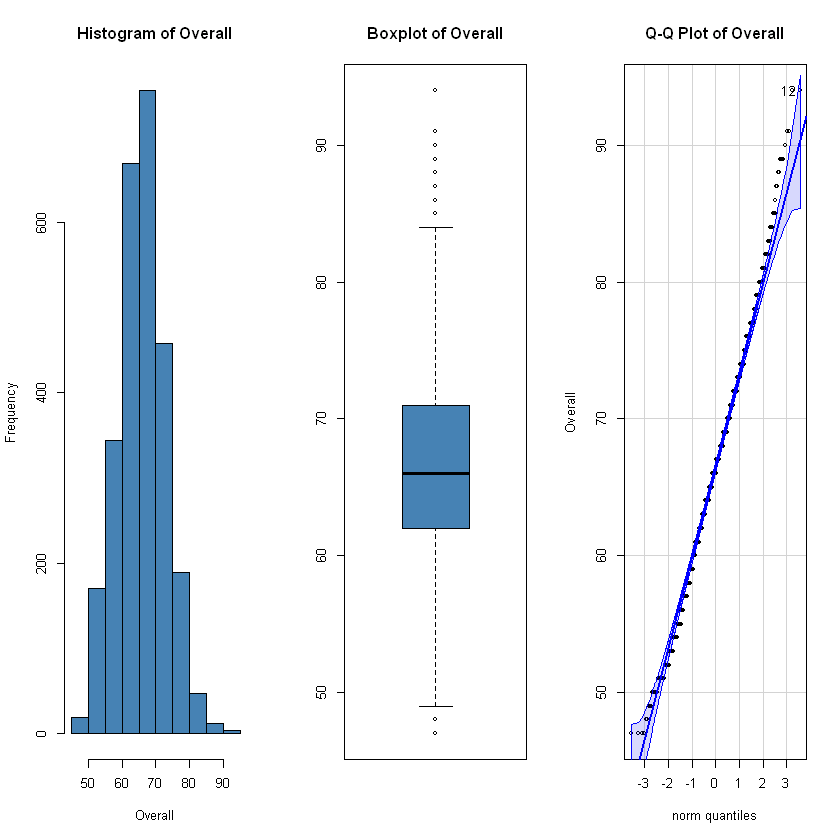

In [33]:
attach(nfifa19_forward_pos)

par(mfrow = c(1, 3))
hist(Overall, main = "Histogram of Overall", xlab = "Overall", col = "steelblue")
boxplot(Overall, main = "Boxplot of Overall", col = "steelblue")
qqPlot(Overall, main = "Q-Q Plot of Overall")

cat("Mean:", mean(Overall), "\n")
cat("SD:", sd(Overall), "\n")
summary(Overall)

### 3.2 Categorical Explanatory Variables

#### `PreferredFoot` (binary)
Boxplots of `Overall` by foot preference show very similar distributions between left- and right-footed players. No major systematic difference in overall rating is apparent.

#### `Height` (3 categories)
Distributions of `Overall` across the three height categories also appear similar, suggesting height alone may not be a strong predictor of overall performance.

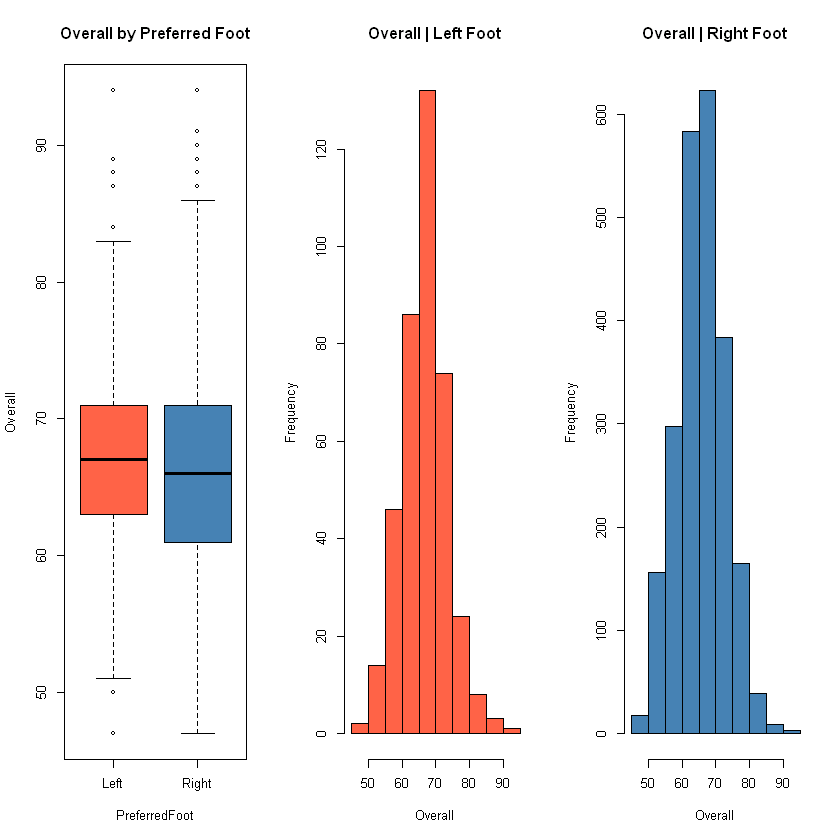

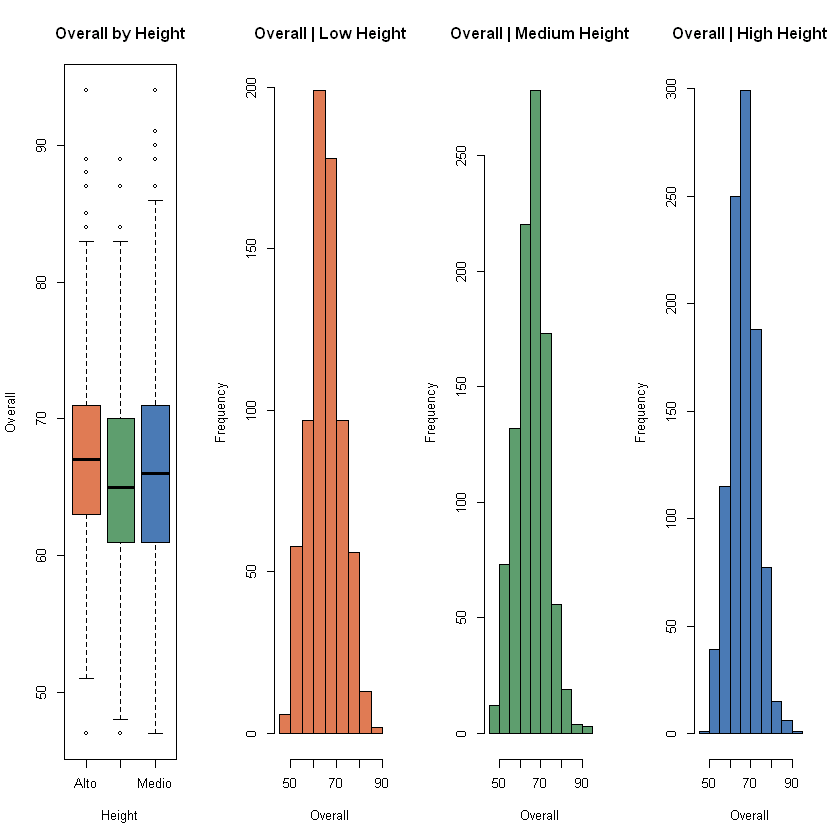

In [34]:
# Preferred Foot
par(mfrow = c(1, 3))
boxplot(Overall ~ PreferredFoot, main = "Overall by Preferred Foot", col = c("tomato", "steelblue"))
hist(Overall[PreferredFoot == "Left"], main = "Overall | Left Foot", xlab = "Overall", col = "tomato")
hist(Overall[PreferredFoot == "Right"], main = "Overall | Right Foot", xlab = "Overall", col = "steelblue")

# Height
par(mfrow = c(1, 4))
boxplot(Overall ~ Height, main = "Overall by Height", col = c("#e07b54", "#5e9e6e", "#4a7ab5"))
hist(Overall[Height == "Baixo"], main = "Overall | Low Height", xlab = "Overall", col = "#e07b54")
hist(Overall[Height == "Medio"], main = "Overall | Medium Height", xlab = "Overall", col = "#5e9e6e")
hist(Overall[Height == "Alto"],  main = "Overall | High Height",  xlab = "Overall", col = "#4a7ab5")

### 3.3 Continuous Explanatory Variables

We inspect the marginal distributions of `Age`, `Weight`, and all mentality scores using histograms and boxplots.

Key observations:
- Most mentality variables (`Positioning`, `Vision`, `Penalties`, `Composure`, `Aggression`) are **approximately symmetrically distributed**.
- **`Age`** and **`Interceptions`** show a clear **right skew** — most forwards are young and forwards tend to have low interception scores by nature of their position.
- No transformations are applied at this stage; the linear regression framework is reasonably robust to moderate non-normality in predictors.

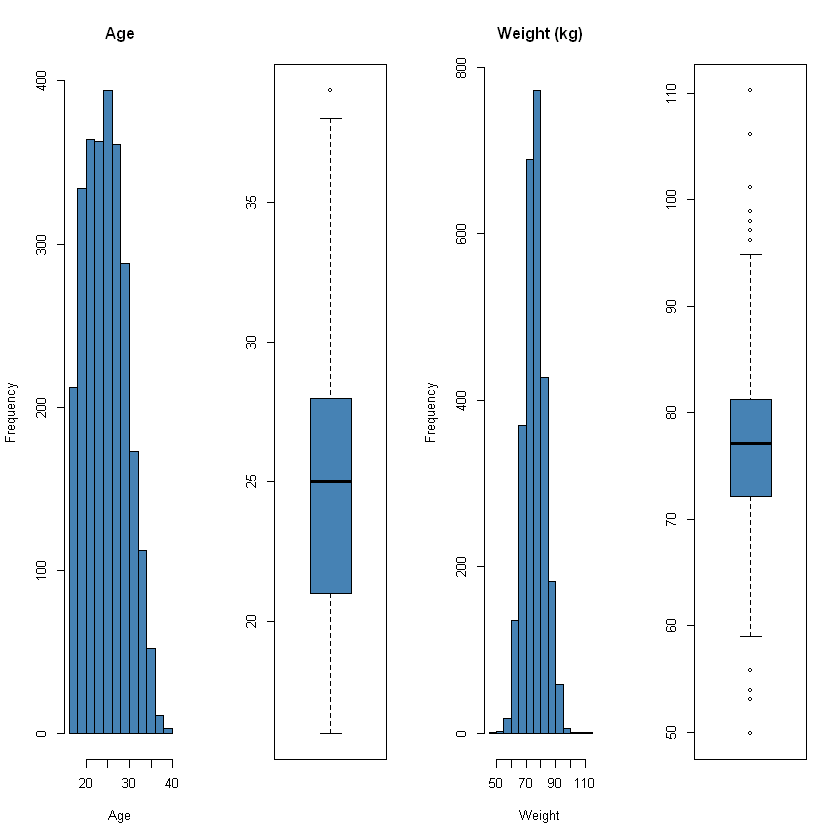

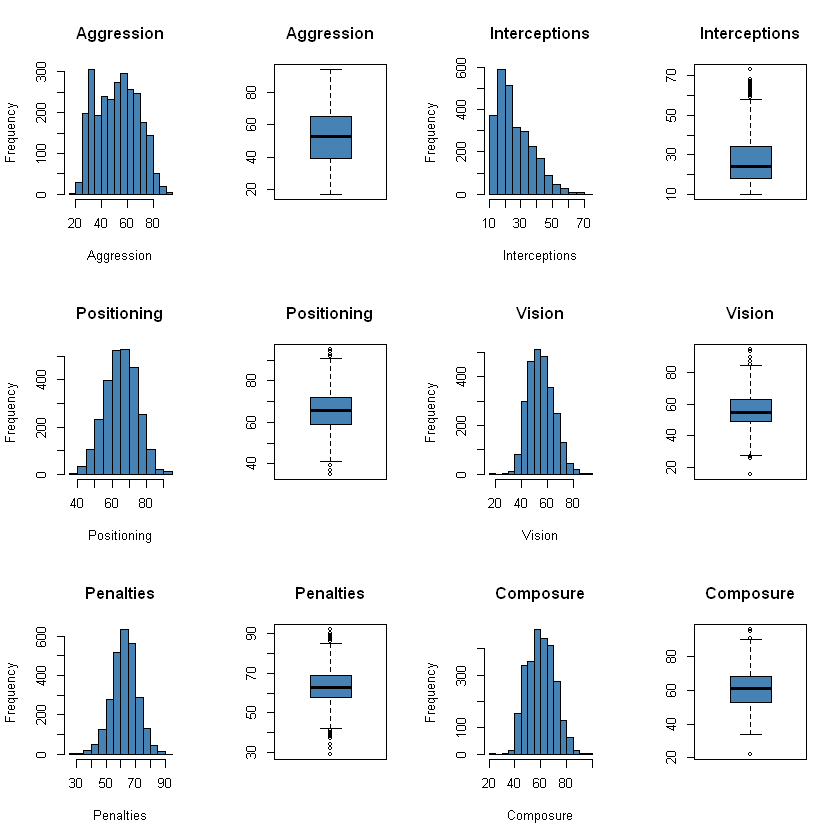

In [35]:
# Age and Weight
par(mfrow = c(1, 4))
hist(Age, main = "Age", col = "steelblue");    boxplot(Age, col = "steelblue")
hist(Weight, main = "Weight (kg)", col = "steelblue"); boxplot(Weight, col = "steelblue")

# Mentality variables
par(mfrow = c(3, 4))
for (var in c("Aggression", "Interceptions", "Positioning", "Vision", "Penalties", "Composure")) {
  hist(get(var), main = var, xlab = var, col = "steelblue")
  boxplot(get(var), main = var, col = "steelblue")
}

### 3.4 Relationship Between Response and Predictors

Scatter plots with LOWESS (locally weighted smoothing) curves reveal the marginal linear relationships between each predictor and `Overall`.

**Visual takeaways:**
- **`Positioning`** and **`Composure`** show the strongest and most linear positive relationship with `Overall` — expected for attacking players.
- `Vision`, `Penalties`, and `Aggression` show moderate positive associations.
- `Age` shows a non-linear (inverted-U) pattern: performance increases through mid-career and then declines.
- `Weight` shows a weak positive trend.
- `Interceptions` has a weak, noisy relationship — unsurprising for forward players who rarely engage in defensive actions.

The following objects are masked from nfifa19_forward_pos (pos = 3):

    Age, Aggression, Composure, Height, Interceptions, Overall,
    Penalties, Positioning, PreferredFoot, Vision, Weight




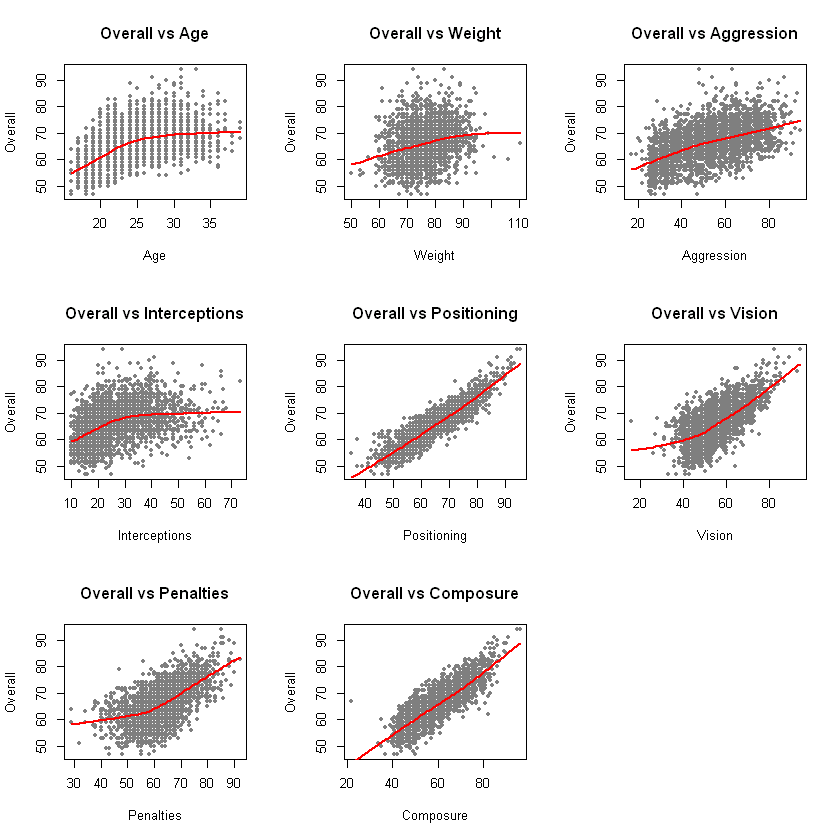

In [36]:
attach(nfifa19_forward_pos)

continuous_vars <- c("Age", "Weight", "Aggression", "Interceptions",
                     "Positioning", "Vision", "Penalties", "Composure")

par(mfrow = c(3, 3))
for (var in continuous_vars) {
  plot(get(var), Overall, main = paste("Overall vs", var),
       xlab = var, ylab = "Overall", pch = 20, col = "grey50")
  lines(lowess(get(var), Overall), col = "red", lwd = 2)
}

### 3.5 Interaction Screening with Categorical Variables

We visually assess whether the linear relationships between `Overall` and continuous predictors **differ across the levels of the categorical variables** — a preliminary check for potential interaction effects.

Coloured LOWESS lines are drawn per category:
- **Height:** Black = Baixo (Low), Red = Médio (Medium), Green = Alto (High)
- **PreferredFoot:** Black = Left, Red = Right

Observation: The slopes appear broadly similar across categories, with no striking divergence. Formal interaction testing will be conducted during modelling.

The following objects are masked from nfifa19_forward_pos (pos = 3):

    Age, Aggression, Composure, Height, Interceptions, Overall,
    Penalties, Positioning, PreferredFoot, Vision, Weight


The following objects are masked from nfifa19_forward_pos (pos = 4):

    Age, Aggression, Composure, Height, Interceptions, Overall,
    Penalties, Positioning, PreferredFoot, Vision, Weight




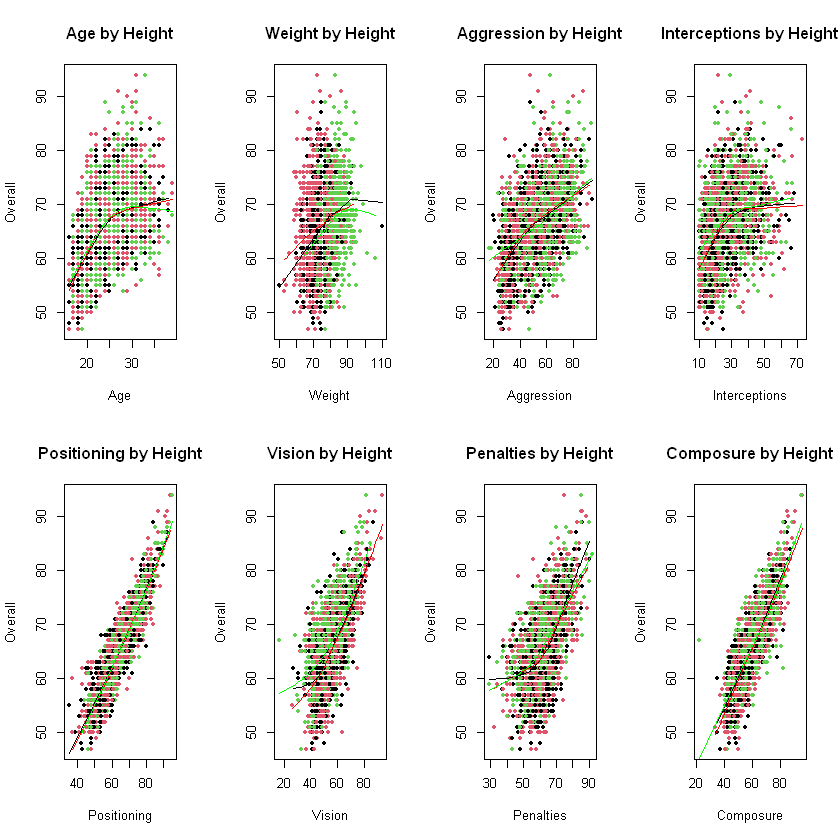

In [ ]:
# Create a numeric version for correlation and interaction plots
nfifa19_corr <- nfifa19_forward_pos

nfifa19_corr$Height <- as.numeric(
  ifelse(nfifa19_forward_pos$Height == "Baixo", 0,
    ifelse(nfifa19_forward_pos$Height == "Alto", 2, 1))
)
nfifa19_corr$PreferredFoot <- as.numeric(
  ifelse(nfifa19_forward_pos$PreferredFoot == "Left", 0, 1)
)
attach(nfifa19_corr)

# Plots by Height category
par(mfrow = c(2, 4))
for (var in c("Age", "Weight", "Aggression", "Interceptions",
              "Positioning", "Vision", "Penalties", "Composure")) {
  x <- get(var)
  plot(x, Overall, col = as.factor(Height),
       main = paste(var, "by Height"), xlab = var, pch = 20)
  lines(lowess(x[Height == 0], Overall[Height == 0]), col = "black")
  lines(lowess(x[Height == 1], Overall[Height == 1]), col = "red")
  lines(lowess(x[Height == 2], Overall[Height == 2]), col = "green")
}

detach(nfifa19_corr)

---
## 4. Correlation Analysis

### 4.1 Correlation Matrix

Before building models, we examine the **Pearson correlation matrix** between all variables. This serves two purposes:
1. Identify predictors with strong associations with `Overall` (candidate predictors)
2. Detect **multicollinearity** — high inter-predictor correlations that can destabilise coefficient estimates

> **Rule of thumb:** Correlations > 0.75 between two predictors indicate potential multicollinearity and warrant further investigation.

Key findings:
- `Positioning` and `Composure` have a correlation of **0.80** — above the 0.75 threshold. This is the only pair raising multicollinearity concerns.
- `Positioning` has the **highest correlation with `Overall`** (r ≈ 0.91), confirming it as the dominant predictor.
- `Vision` (r ≈ 0.68) and `Composure` (r ≈ 0.83) also have strong associations with `Overall`.

,Overall,Age,Height,Weight,PreferredFoot,Aggression,Interceptions,Positioning,Vision,Penalties,Composure
Overall,1.00,0.53,0.08,0.23,-0.05,0.51,0.40,0.91,0.68,0.59,0.83
Age,0.53,1.00,0.08,0.24,-0.01,0.47,0.41,0.55,0.43,0.41,0.56
Height,0.08,0.08,1.00,0.45,-0.02,0.17,0.02,0.10,-0.04,0.01,0.09
Weight,0.23,0.24,0.45,1.00,-0.02,0.34,0.06,0.23,0.02,0.13,0.20
PreferredFoot,-0.05,-0.01,-0.02,-0.02,1.00,-0.01,-0.01,-0.03,-0.04,-0.01,-0.04
Aggression,0.51,0.47,0.17,0.34,-0.01,1.00,0.46,0.49,0.35,0.28,0.50
Interceptions,0.40,0.41,0.02,0.06,-0.01,0.46,1.00,0.38,0.44,0.16,0.42
Positioning,0.91,0.55,0.10,0.23,-0.03,0.49,0.38,1.00,0.61,0.55,0.80
Vision,0.68,0.43,-0.04,0.02,-0.04,0.35,0.44,0.61,1.00,0.45,0.68
Penalties,0.59,0.41,0.01,0.13,-0.01,0.28,0.16,0.55,0.45,1.00,0.54


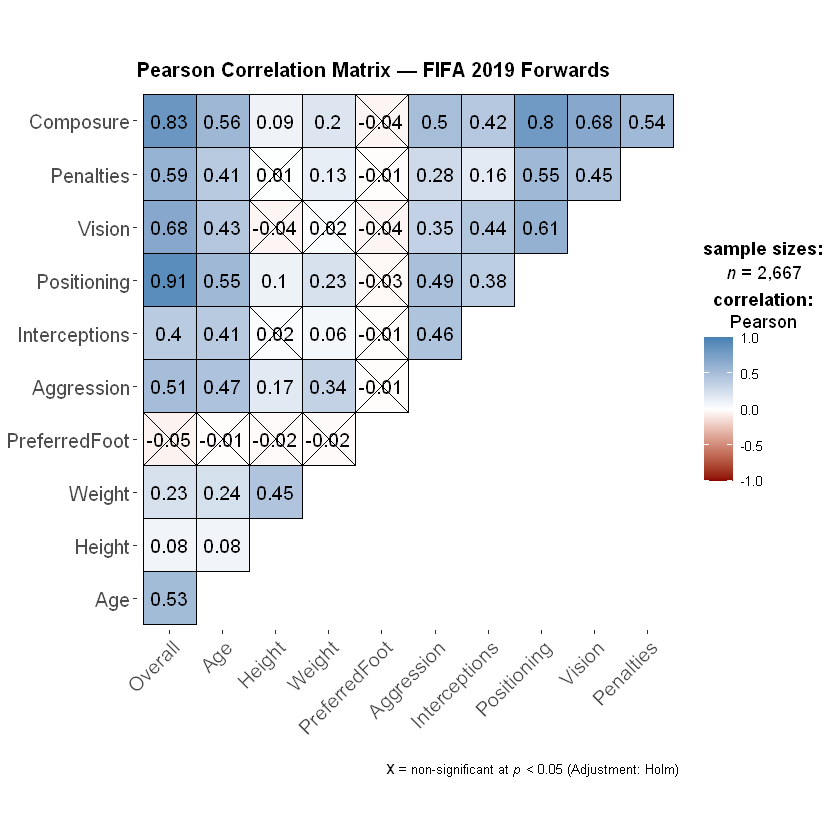

In [38]:
# Pearson correlation matrix (numeric encoding of categoricals for computation)
round(cor(nfifa19_corr), 2)

# Visual correlation matrix
ggcorrmat(
  data   = nfifa19_corr,
  type   = "parametric",
  colors = c("darkred", "white", "steelblue"),
  title  = "Pearson Correlation Matrix — FIFA 2019 Forwards"
)

### 4.2 Investigating the Highly Correlated Pair

We take a closer look at the three pairs with the highest inter-predictor correlations:
- `Composure` vs `Positioning` (r = 0.80)
- `Composure` vs `Vision` (r = 0.68)
- `Positioning` vs `Vision` (r = 0.61)

The scatter plots with LOWESS lines confirm a **strong linear relationship between `Positioning` and `Composure`**. This multicollinearity will be addressed during model selection.

The following objects are masked from nfifa19_forward_pos (pos = 3):

    Age, Aggression, Composure, Height, Interceptions, Overall,
    Penalties, Positioning, PreferredFoot, Vision, Weight


The following objects are masked from nfifa19_forward_pos (pos = 4):

    Age, Aggression, Composure, Height, Interceptions, Overall,
    Penalties, Positioning, PreferredFoot, Vision, Weight




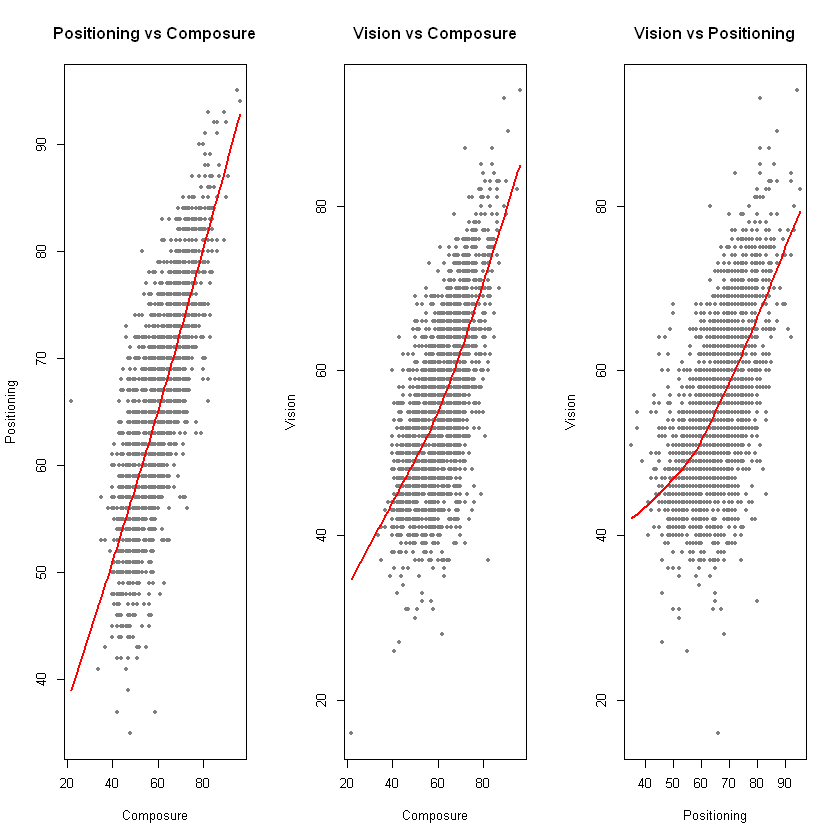

In [39]:
attach(nfifa19_corr)

par(mfrow = c(1, 3))
plot(Composure, Positioning, pch = 20, col = "grey50", main = "Positioning vs Composure")
lines(lowess(Composure, Positioning), col = "red", lwd = 2)

plot(Composure, Vision, pch = 20, col = "grey50", main = "Vision vs Composure")
lines(lowess(Composure, Vision), col = "red", lwd = 2)

plot(Positioning, Vision, pch = 20, col = "grey50", main = "Vision vs Positioning")
lines(lowess(Positioning, Vision), col = "red", lwd = 2)

detach(nfifa19_corr)

---
## 5. Multiple Linear Regression — Model Building

### Framework

A **multiple linear regression** model assumes a linear relationship between the response $Y$ and $p$ predictor variables $X_1, \ldots, X_p$:

$$Y_i = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p + u, \quad u \sim N(0, \sigma^2 \cdot I_d)$$

The assumptions that must be satisfied for valid inference are:
1. **Normality of residuals:** Residuals follow a normal distribution
2. **Homoscedasticity:** the variance of the response variable Y should be constant for all values of X. The residuals should be homoscedastic.
3. **Independence:** Residuals are independent of each other
4. **Linearity:** The relationship between response and explanatory variables is linear
5. **Zero mean residuals:** the expected value for the residuals is zero $E(u) = 0$

Beyond these assumptions, we also assess **outliers** and **multicollinearity**.

### Model Selection Strategy

We follow a **backward elimination** approach:
1. Fit a full model with all 10 predictors (Model 1)
2. Assess significance of each predictor
3. Before removing non-significant predictors, **test for interactions** involving those variables
4. Remove non-significant predictors one at a time, re-evaluating after each removal
5. Address multicollinearity by removing redundant predictors

### 5.1 Model 1 — Full Model (All 10 Predictors)

The parameter estimates are shown together with their respective standard errors, the t-statistic, and the associated p-value, which tests whether the estimates are different from zero:

$$
H_0: \beta_j = 0, \quad \text{for each } j = 0, \ldots, p
$$

In [40]:
attach(nfifa19_forward_pos)

modelo1 <- lm(
  Overall ~ Age + Height + Weight + PreferredFoot +
    Aggression + Interceptions + Positioning + Vision + Penalties + Composure,
  data = nfifa19_forward_pos
)
summary(modelo1)

The following objects are masked from nfifa19_forward_pos (pos = 3):

    Age, Aggression, Composure, Height, Interceptions, Overall,
    Penalties, Positioning, PreferredFoot, Vision, Weight


The following objects are masked from nfifa19_forward_pos (pos = 4):

    Age, Aggression, Composure, Height, Interceptions, Overall,
    Penalties, Positioning, PreferredFoot, Vision, Weight





Call:
lm(formula = Overall ~ Age + Height + Weight + PreferredFoot + 
    Aggression + Interceptions + Positioning + Vision + Penalties + 
    Composure, data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.4273 -1.5778 -0.0785  1.5859 11.8797 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        15.123107   0.777461  19.452  < 2e-16 ***
Age                -0.073996   0.013446  -5.503 4.09e-08 ***
HeightBaixo         0.222728   0.137475   1.620  0.10532    
HeightMedio         0.156405   0.133468   1.172  0.24136    
Weight              0.040307   0.009002   4.477 7.88e-06 ***
PreferredFootRight -0.374559   0.136672  -2.741  0.00617 ** 
Aggression          0.023906   0.003955   6.044 1.72e-09 ***
Interceptions       0.001013   0.005297   0.191  0.84838    
Positioning         0.466240   0.009262  50.337  < 2e-16 ***
Vision              0.097323   0.007145  13.621  < 2e-16 ***
Penalties           0.069688   0.0070

**Model 1 Results:**
- $R^2 = 0.8761$, Adjusted $R^2 = 0.8755$ — the model explains ~88% of variance in `Overall`
- Residual Standard Error: **2.49** and residual median of -0.0785
- **7 variables** are significant at p < 0.001
- `PreferredFootRight` is significant at p < 0.01
- **3 variables are NOT significant** (p > 0.05): `HeightBaixo`, `HeightAlto`, and `Interceptions`

Before removing `Height` and `Interceptions`, we must check whether they participate in **significant interactions** with other predictors — a non-significant main effect can still be required to maintain a meaningful interaction term.

### 5.2 Model 1.1 — Testing All Interactions

We expand Model 1 by adding **all pairwise interactions** involving the non-significant variables (`Interceptions` and `Height`) and every other predictor.

In [41]:
modelo1.1 <- lm(
  Overall ~ Age + Height + Weight + PreferredFoot +
    Aggression + Interceptions + Positioning + Vision + Penalties + Composure +
    Interceptions * Age + Interceptions * Height + Interceptions * Weight +
    Interceptions * PreferredFoot + Interceptions * Aggression +
    Interceptions * Positioning + Interceptions * Vision +
    Interceptions * Penalties + Interceptions * Composure +
    Height * Age + Height * Weight + Height * PreferredFoot +
    Height * Aggression + Height * Positioning + Height * Vision +
    Height * Penalties + Height * Composure,
  data = nfifa19_forward_pos
)
summary(modelo1.1)


Call:
lm(formula = Overall ~ Age + Height + Weight + PreferredFoot + 
    Aggression + Interceptions + Positioning + Vision + Penalties + 
    Composure + Interceptions * Age + Interceptions * Height + 
    Interceptions * Weight + Interceptions * PreferredFoot + 
    Interceptions * Aggression + Interceptions * Positioning + 
    Interceptions * Vision + Interceptions * Penalties + Interceptions * 
    Composure + Height * Age + Height * Weight + Height * PreferredFoot + 
    Height * Aggression + Height * Positioning + Height * Vision + 
    Height * Penalties + Height * Composure, data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.2974 -1.5746 -0.0472  1.5898 10.0886 

Coefficients:
                                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)                       1.202e+01  2.297e+00   5.234 1.79e-07 ***
Age                               7.317e-02  3.993e-02   1.833 0.066973 .  
HeightBaixo                      -2.418e-01

**Significant interactions found (p < 0.05):**
- `Interceptions × Age` (p < 0.001)
- `Height × Positioning` (p < 0.001)
- `Height × Composure` (p < 0.05)

Model 1.1 fit: $R^2 = 0.8804$, Adjusted $R^2 = 0.8788$, RSE = 2.457

### 5.3 Model 1.2 — Pruned Interaction Model

We retain only the **significant interactions** from Model 1.1, removing the 14 non-significant interaction terms.

In [42]:
modelo1.2 <- lm(
  Overall ~ Age + Height + Weight + PreferredFoot +
    Aggression + Interceptions + Positioning + Vision + Penalties + Composure +
    Interceptions * Age + Height * Age + Height * Positioning + Height * Composure,
  data = nfifa19_forward_pos
)
summary(modelo1.2)


Call:
lm(formula = Overall ~ Age + Height + Weight + PreferredFoot + 
    Aggression + Interceptions + Positioning + Vision + Penalties + 
    Composure + Interceptions * Age + Height * Age + Height * 
    Positioning + Height * Composure, data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.0705 -1.5719 -0.0689  1.5636 10.4528 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)             10.5444213  1.1131789   9.472  < 2e-16 ***
Age                      0.0687758  0.0341604   2.013 0.044182 *  
HeightBaixo              0.6405651  0.9103392   0.704 0.481709    
HeightMedio              0.0382388  0.8427689   0.045 0.963814    
Weight                   0.0396488  0.0089114   4.449 8.97e-06 ***
PreferredFootRight      -0.3449249  0.1349638  -2.556 0.010653 *  
Aggression               0.0215650  0.0039209   5.500 4.16e-08 ***
Interceptions            0.1844110  0.0266791   6.912 5.96e-12 ***
Positioning        

### 5.4 Model Comparison: Model 1 vs Model 1.2 (ANOVA F-test)

To formally test whether the interaction terms in Model 1.2 provide a statistically significant improvement over the simpler Model 1, we use an **F-test for nested models** (ANOVA).

**Hypotheses:**
- $H_0$: The goodness of fit of Model 1 (reduced) equals that of Model 1.2 (full)
- $H_1$: Model 1.2 provides a significantly better fit

The F-test is **significant** ($F = 11.25$, $p < 10^{-13}$), so we reject $H_0$ — the interactions do improve the model fit. **However**, the practical improvement in $R^2$ is minimal (0.8761 vs 0.8796), and the residual diagnostics are nearly identical between both models. On grounds of **parsimony**, **Model 1** (without interactions) is chosen as the preferred starting point for further simplification.

In [43]:
anova(modelo1, modelo1.2)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2655,16460.64,NA,NA,NA,NA
2,2648,15985.31,7,475.3374,11.24866,4.117677e-14


#### residual diagnostics

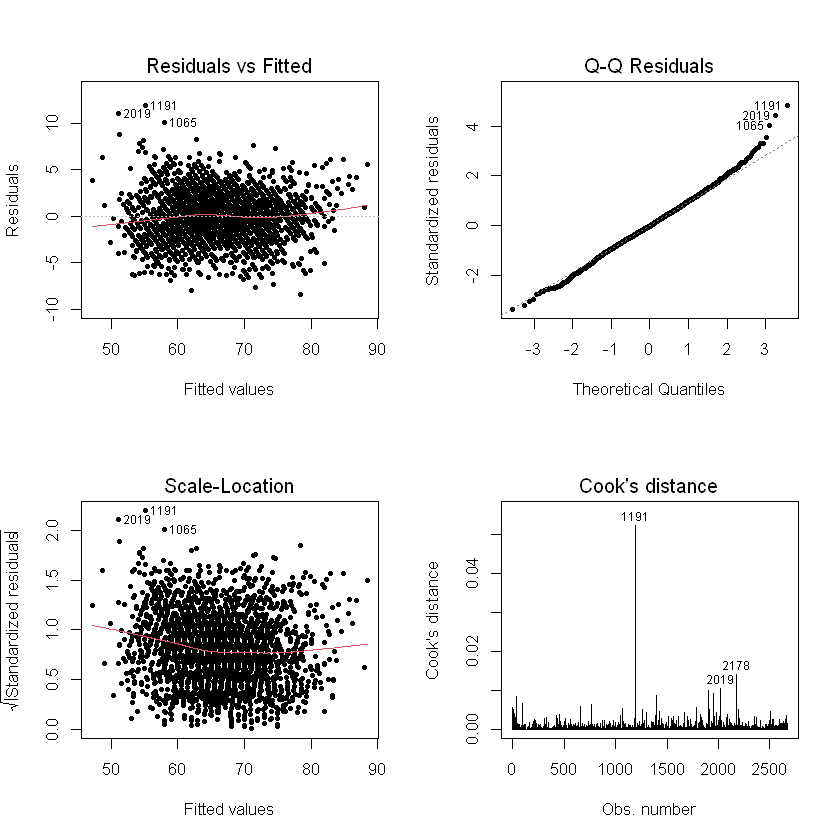

In [44]:
par(mfrow=c(2,2))
plot(modelo1, which=c(1:4), pch=20)

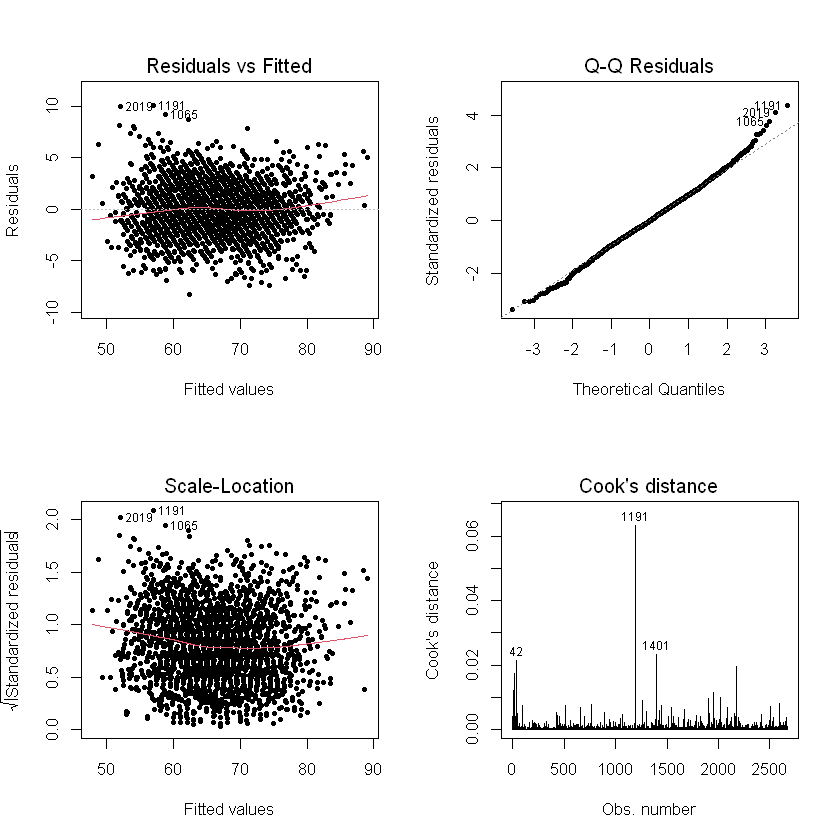

In [45]:
par(mfrow=c(2,2))
plot(modelo1.1, which=c(1:4), pch=20)

### 5.5 Model 2 — Remove `Interceptions`

The first non-significant predictor to be removed is `Interceptions`. This is consistent with domain knowledge: **forward players** are rarely involved in defensive interceptions, so this skill is not expected to differentiate their overall ratings.

In [47]:
modelo2 <- lm(
  Overall ~ Age + Height + Weight + PreferredFoot +
    Aggression + Positioning + Vision + Penalties + Composure,
  data = nfifa19_forward_pos
)
summary(modelo2)


Call:
lm(formula = Overall ~ Age + Height + Weight + PreferredFoot + 
    Aggression + Positioning + Vision + Penalties + Composure, 
    data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.4160 -1.5758 -0.0727  1.5881 11.9104 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        15.128829   0.776744  19.477  < 2e-16 ***
Age                -0.073530   0.013221  -5.562 2.94e-08 ***
HeightBaixo         0.222823   0.137449   1.621  0.10511    
HeightMedio         0.156074   0.133432   1.170  0.24223    
Weight              0.040155   0.008966   4.479 7.83e-06 ***
PreferredFootRight -0.374496   0.136647  -2.741  0.00617 ** 
Aggression          0.024121   0.003790   6.364 2.31e-10 ***
Positioning         0.466275   0.009259  50.359  < 2e-16 ***
Vision              0.097635   0.006955  14.038  < 2e-16 ***
Penalties           0.069470   0.006910  10.053  < 2e-16 ***
Composure           0.137309   0.008937  15.364  < 2e

The F-test comparing Model 1 and Model 2 is **not significant**, confirming that `Interceptions` can be safely removed without meaningful loss in explanatory power. Furthermore, $R^1$ and $R^2$ are pretty much the same, and the residual standard error and residual diagnostics are nearly identical between both models.

In [48]:
# F-test: Model 1 vs Model 2
anova(modelo1, modelo2)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2655,16460.64,NA,NA,NA,NA
2,2656,16460.87,-1,-0.2266767,0.03656155,0.8483751


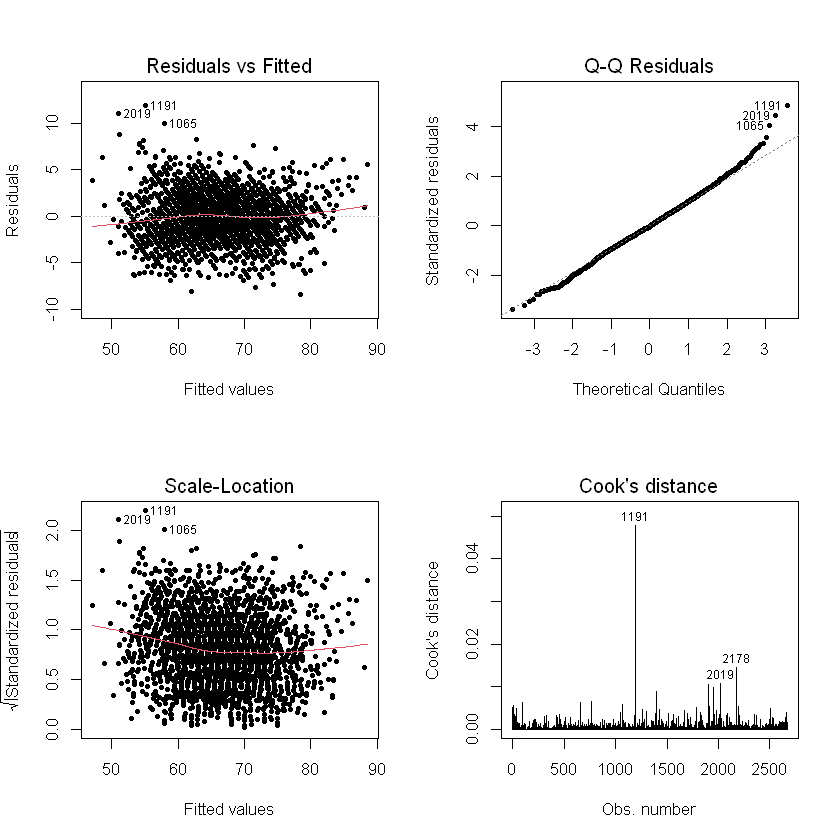

In [49]:
par(mfrow=c(2,2))
plot(modelo2, which=c(1:4), pch=20)

### 5.6 Model 3 — Remove `Height`

Next, `Height` (which has two non-significant dummy coefficients) is removed from Model 2.

In [50]:
modelo3 <- lm(
  Overall ~ Age + Weight + PreferredFoot +
    Aggression + Positioning + Vision + Penalties + Composure,
  data = nfifa19_corr
)
summary(modelo3)

# F-test: Model 2 vs Model 3
anova(modelo2, modelo3)


Call:
lm(formula = Overall ~ Age + Weight + PreferredFoot + Aggression + 
    Positioning + Vision + Penalties + Composure, data = nfifa19_corr)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.4427 -1.5947 -0.0819  1.5818 11.7993 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   15.717421   0.667163  23.559  < 2e-16 ***
Age           -0.072614   0.013205  -5.499 4.18e-08 ***
Weight         0.033396   0.007661   4.359 1.35e-05 ***
PreferredFoot -0.371781   0.136655  -2.721  0.00656 ** 
Aggression     0.023891   0.003788   6.307 3.33e-10 ***
Positioning    0.465840   0.009252  50.352  < 2e-16 ***
Vision         0.098362   0.006939  14.176  < 2e-16 ***
Penalties      0.070066   0.006902  10.152  < 2e-16 ***
Composure      0.137008   0.008928  15.346  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.49 on 2658 degrees of freedom
Multiple R-squared:  0.8759,	Adjusted R-squared:  0.8756 
F-

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2656,16460.87,NA,NA,NA,NA
2,2658,16477.64,-2,-16.76471,1.352513,0.2587677


Again, the F-test is **not significant** — `Height` can be removed without loss.

Model 3 results: $R^2 = 0.8759$, Adjusted $R^2 = 0.8756$, RSE = 2.49. Again, very similar to those in Model 1.

### 5.7 Model 4 — Address Multicollinearity: Remove `Composure`

As established in Section 4.1, `Positioning` and `Composure` are highly correlated (r = 0.80). Retaining both in the same model leads to **inflated standard errors** and **unstable coefficient estimates** due to multicollinearity.

**Decision:** Remove `Composure`, because:
- Its **standardised regression coefficient** (β = 0.199) is considerably smaller than that of `Positioning` (β = 0.611) in Model 3
- `Positioning` is directly tied to forward play (scoring goals, receiving passes) and is more conceptually valid as a predictor of overall performance for strikers

We compare Model 3 and Model 4 with an F-test.

In [51]:
modelo4 <- lm(
  Overall ~ Age + Weight + PreferredFoot +
    Aggression + Positioning + Vision + Penalties,
  data = nfifa19_forward_pos
)
summary(modelo4)

# F-test: Model 3 vs Model 4
anova(modelo3, modelo4)


Call:
lm(formula = Overall ~ Age + Weight + PreferredFoot + Aggression + 
    Positioning + Vision + Penalties, data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.8636 -1.6757 -0.0328  1.6569 11.5326 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        14.726209   0.692689  21.259  < 2e-16 ***
Age                -0.045235   0.013649  -3.314 0.000931 ***
Weight              0.038215   0.007985   4.786 1.79e-06 ***
PreferredFootRight -0.432043   0.142494  -3.032 0.002453 ** 
Aggression          0.032379   0.003909   8.283  < 2e-16 ***
Positioning         0.539587   0.008247  65.430  < 2e-16 ***
Vision              0.137421   0.006733  20.409  < 2e-16 ***
Penalties           0.083396   0.007142  11.677  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.597 on 2659 degrees of freedom
Multiple R-squared:  0.8649,	Adjusted R-squared:  0.8646 
F-statistic:  243

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2658,16477.64,NA,NA,NA,NA
2,2659,17937.50,-1,-1459.863,235.4899,5.448607e-51


The F-test is **significant** here — removing `Composure` does reduce model fit. However, the adjusted $R^2$ drops only marginally (0.8756 → 0.8646), and the residual diagnostics remain comparable. Given the multicollinearity concern, **Model 4 is selected as the final model** as it is more interpretable and statistically sound.


### 5.8 Standardised Regression Coefficients

Standardised (beta) coefficients allow direct comparison of predictor effect sizes by putting all variables on the same scale (mean = 0, variance = 1). They answer: *by how many standard deviations does `Overall` change when predictor $X_j$ increases by one standard deviation?*

Adjusted effect: the explanatory variable `Positioning` is the variable (a mentality-related characteristic) that best explains or influences the overall rating of forward players, with an adjusted effect of 0.708. It is followed by `Vision` and `Penalties`, with adjusted effects of 0.191 and 0.102, respectively.

* Example `Positioning`: Any increase of 1 standard deviation in `Positioning` score predicts a increase of approx. 0.7 standard deviations in `Overall`, holding the other explanatory variables constant /adjusting for the other explanatory variables.

* Example `Age`: Any increase of 1 standard deviation in `Age` predicts a decrease of approx. 0.03 standard deviations in `Overall`, holding the other explanatory variables constant /adjusting for the other explanatory variables.

In [53]:
cat("Standardised Coefficients — Model 4:\n")
lm.beta(modelo4)

Standardised Coefficients — Model 4:


Warning message in var(if (is.vector(x) || is.factor(x)) x else as.double(x), na.rm = na.rm):
"NAs introduced by coercion"


Age             Weight PreferredFootRight         Aggression 
       -0.03015161         0.03715640                 NA         0.07291189 
       Positioning             Vision          Penalties 
        0.70766127         0.19125908         0.10219164

In [54]:
anova(modelo4)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,37167.3057,37167.305686,5509.56761,0.000000e+00
Weight,1,1587.2979,1587.297869,235.29618,5.947420e-51
PreferredFoot,1,262.4662,262.466170,38.90718,5.154075e-10
Aggression,1,10440.1277,10440.127738,1547.61257,3.557502e-267
Positioning,1,61067.6478,61067.647829,9052.48116,0.000000e+00
Vision,1,3424.9509,3424.950866,507.70423,4.915220e-103
Penalties,1,919.7513,919.751288,136.34112,9.338213e-31
Residuals,2659,17937.4994,6.745957,NA,NA


---
## 6. Final Model — Summary and Interpretation

### Model 4 — The Final Model

$$\hat{\text{Overall}} = 14.73 - 0.045 \cdot \text{Age} + 0.038 \cdot \text{Weight} - 0.432 \cdot \text{PreferredFootRight} + 0.032 \cdot \text{Aggression} + 0.540 \cdot \text{Positioning} + 0.137 \cdot \text{Vision} + 0.083 \cdot \text{Penalties}$$

**Performance metrics:**
- $R^2 = 0.8649$ — the model explains **86.5%** of the variance in `Overall`
- Adjusted $R^2 = 0.8646$
- Residual Standard Error: **2.597** (on the 1–99 Overall scale, this is excellent)
- F-statistic: **2433** (p < 2.2×10⁻¹⁶) — the model is highly significant overall

**Coefficient interpretation:**

* Positioning (**Dominant predictor**): Any 1-unit increase in `Positioning` score predicts an increase of 0.54 in `Overall`, after adjustment for the other explanatory variables.

* Vision: Any 1-unit increase in `Vision` score predicts an increase of 0.14 in `Overall`, after adjustment for the other explanatory variables.

* Age: Any 1-year increase in `Age` predicts a decrease of 0.045 in `Overall`, after adjustment for the other explanatory variables

---
## 7. Residual Analysis and Model Diagnostics

We now rigorously evaluate whether the assumptions of linear regression hold for Model 4.

### 7.1 Overview

The key plots to examine are:
1. **Residuals vs Fitted** → linearity and homoscedasticity
2. **Normal Q-Q** → normality of residuals
3. **Scale-Location** → homoscedasticity (constant variance)
4. **Residuals vs Leverage** → influential observations

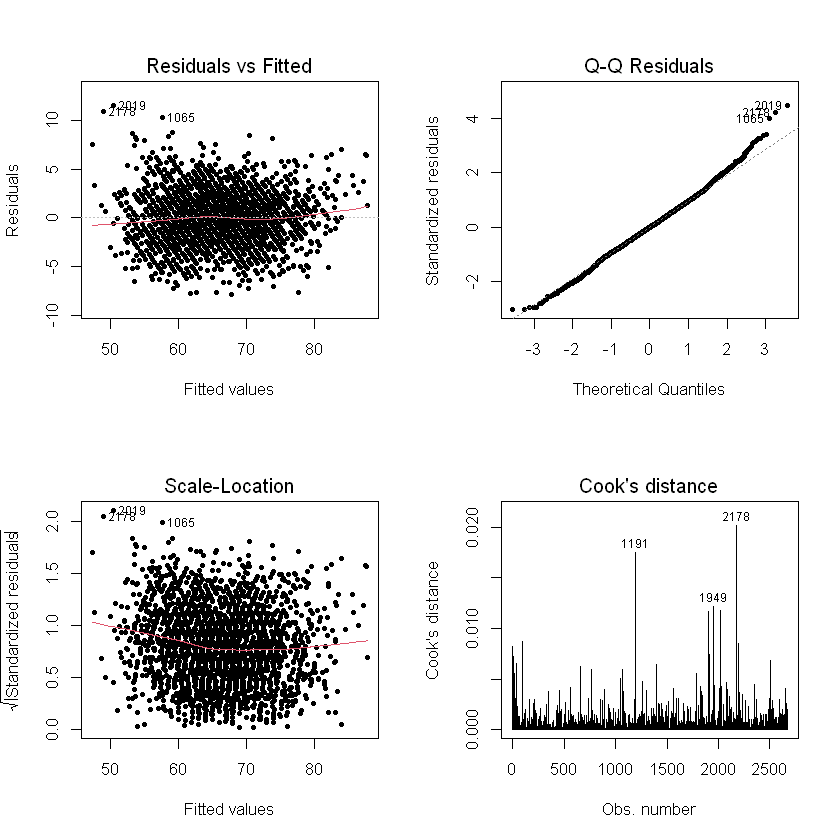

In [57]:
par(mfrow = c(2, 2))
plot(modelo4, which = c(1:4), pch = 20)

### 7.2 Normality of Residuals

The histogram, boxplot, and Q-Q plot of standardised residuals indicate an **approximately normal distribution**. There are some deviations in the tails due to outlying observations, but:
- The Q-Q plot closely follows the theoretical line for most of the range
- With n = 2,667 observations, the **Central Limit Theorem** compensates for minor departures
- ✅ **Normality assumption is satisfied**

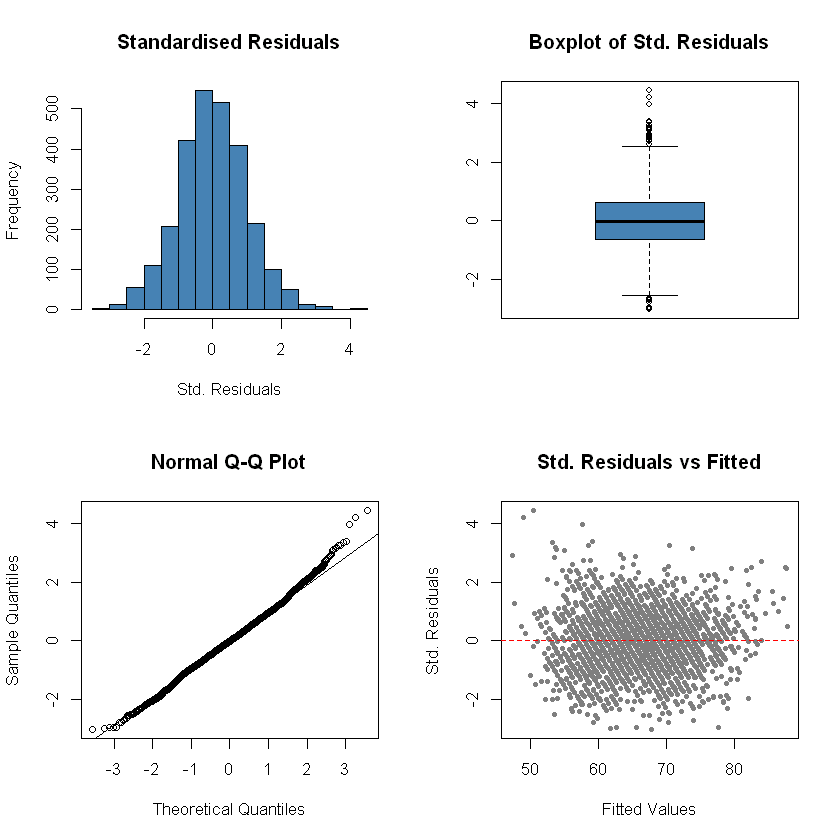

In [58]:
par(mfrow = c(2, 2))
hist(rstandard(modelo4), main = "Standardised Residuals",
     xlab = "Std. Residuals", col = "steelblue")
boxplot(rstandard(modelo4), main = "Boxplot of Std. Residuals", col = "steelblue")
qqnorm(rstandard(modelo4))
qqline(rstandard(modelo4))
plot(fitted.values(modelo4), rstandard(modelo4),
     main = "Std. Residuals vs Fitted",
     xlab = "Fitted Values", ylab = "Std. Residuals", pch = 20, col = "grey50")
abline(0, 0, lty = "dashed", col = "red")

### 7.3 Homoscedasticity (Constant Variance)

The residuals vs fitted values plot shows a broadly random scatter around zero with no strong funnel pattern. However, approximately **5 observations** have standardised residuals exceeding ±3.3 — these are potential outliers.

The slight separation of these extreme points is visually notable, but does not constitute a severe violation. With over 2,600 observations, the model is robust to a handful of outliers.
- ✅ **Homoscedasticity assumption is largely satisfied**

### 7.4 Response vs Fitted Values

Warning message in rlm.default(x, y, weights, method = method, wt.method = wt.method, :
"'rlm' failed to converge in 20 steps"


[1] 2019 2178

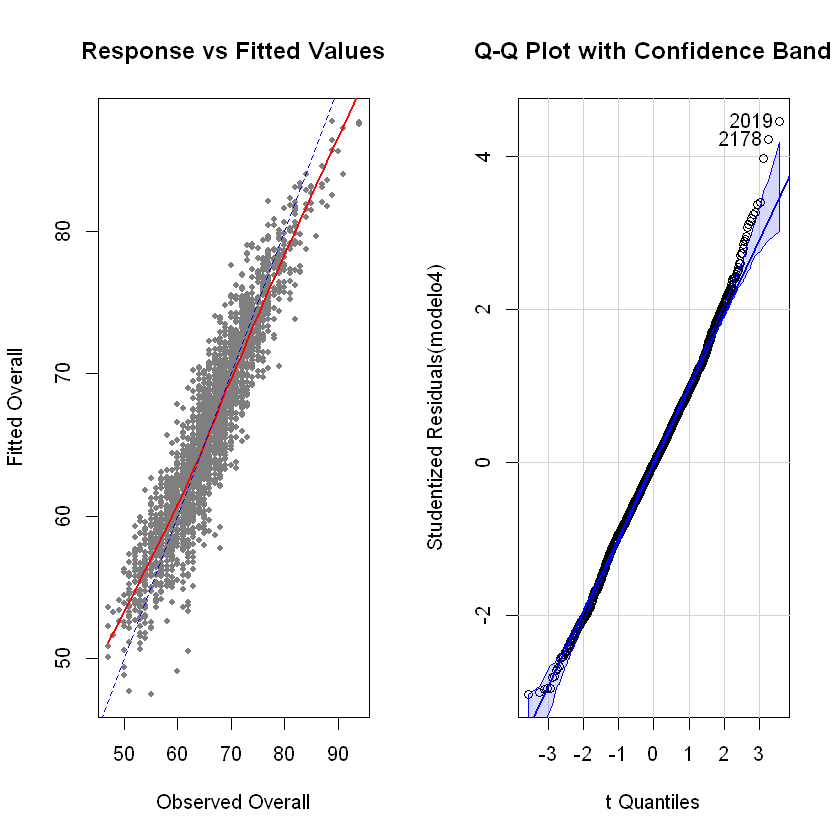

In [59]:
par(mfrow = c(1, 2))

# Response vs Fitted
plot(Overall, fitted.values(modelo4),
     main = "Response vs Fitted Values",
     xlab = "Observed Overall", ylab = "Fitted Overall",
     pch = 20, col = "grey50")
lines(lowess(Overall, fitted.values(modelo4)), col = "red", lwd = 2)
abline(0, 1, lty = "dashed", col = "blue")

# Enhanced Q-Q plot
qqPlot(modelo4, main = "Q-Q Plot with Confidence Band")

### 7.5 Outlier Detection

We identify observations with **|standardised residual| > 3.3** (a conservative threshold for outliers in large samples).

In [60]:
outlier_idx <- which(abs(rstandard(modelo4)) > 3.3)
cat("Observations with |standardised residual| > 3.3:\n")
print(outlier_idx)
cat("\nTotal outliers:", length(outlier_idx), "out of", nrow(nfifa19_forward_pos), "\n")

# Inspect the outlying observations
nfifa19_forward_pos[outlier_idx, ]

Observations with |standardised residual| > 3.3:
1065 1071 1949 2019 2178 
1065 1071 1949 2019 2178 

Total outliers: 5 out of 2667 


Overall,Age,Height,Weight,PreferredFoot,Aggression,Interceptions,Positioning,Vision,Penalties,Composure
<dbl>,<dbl>,<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
68,25,Baixo,77.1120,Right,31,17,54,42,68,51
68,26,Baixo,73.0296,Right,44,21,57,48,54,70
62,33,Alto,74.8440,Right,30,16,45,50,66,56
62,23,Baixo,76.2048,Right,52,28,46,27,49,43
60,28,Medio,74.8440,Right,52,44,37,55,48,59


### 7.6 Influential Observations (Leverage & Cook's Distance)

- **Leverage** threshold: 2(p+1)/n ≈ 0.006, traditional cut-off often cited at 0.055 for this sample size
- **Cook's Distance** threshold: 1.0

From the Residuals vs Leverage plot: **no observation has Cook's distance > 0.02**, and no leverages exceed 0.055.
- ✅ **No influential observations detected** — the model is not driven by any single data point

---
## 8. Multicollinearity — Detailed Assessment

Multicollinearity refers to the presence of near-linear dependencies between predictor variables. High multicollinearity:
- Inflates standard errors of coefficients
- Makes individual coefficient estimates unstable
- Reduces interpretability without harming prediction

**Detection approach:** Pearson correlation matrix — pairs with |r| > 0.75 are flagged.

The only flagged pair was **`Positioning` and `Composure`** (r = 0.80). This was resolved by removing `Composure` from the final model, retaining `Positioning` due to its substantially larger standardised coefficient and stronger conceptual relevance to forward play.

> In Model 3 (before removal), standardised β for `Positioning` was **0.611** vs **0.199** for `Composure` — positioning carries more than 3× the effect on `Overall`.

---
## 9. Specific Analysis — Model E (Including `Height` for Inference)

Since `Height` was removed from the final model, we construct **Model E** specifically to answer inference questions involving `Height` as a categorical predictor. This model includes `Height` alongside the other significant predictors.

- Continuous predictor of focus: **`Positioning`** ($X_1$)
- Categorical predictor of focus: **`Height`** ($X_2$, 3 levels: Baixo, Médio, Alto)

In [55]:
modelo_e <- lm(
  Overall ~ Age + Height + Weight + PreferredFoot +
    Aggression + Positioning + Vision + Penalties,
  data = nfifa19_forward_pos
)
summary(modelo_e)


Call:
lm(formula = Overall ~ Age + Height + Weight + PreferredFoot + 
    Aggression + Positioning + Vision + Penalties, data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.9048 -1.6723 -0.0302  1.6647 11.4632 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        14.136483   0.807569  17.505  < 2e-16 ***
Age                -0.046230   0.013668  -3.382 0.000729 ***
HeightBaixo         0.164918   0.143347   1.150 0.250047    
HeightMedio         0.187621   0.139193   1.348 0.177798    
Weight              0.045118   0.009348   4.827 1.47e-06 ***
PreferredFootRight -0.434062   0.142506  -3.046 0.002342 ** 
Aggression          0.032596   0.003913   8.331  < 2e-16 ***
Positioning         0.540129   0.008256  65.422  < 2e-16 ***
Vision              0.136692   0.006754  20.238  < 2e-16 ***
Penalties           0.082919   0.007151  11.595  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Re

### 9.1 Crude vs Adjusted Effect of `Positioning`

- **Crude (unadjusted) effect** = coefficient from a **simple linear regression** of `Overall` on `Positioning` alone (Model E1)
- **Adjusted effect** = coefficient from the full Model E, controlling for all other predictors.

In [61]:
# Crude effect (simple regression)
modelo_e1 <- lm(Overall ~ Positioning, data = nfifa19_forward_pos)
summary(modelo_e1)

cat("\n--- Summary ---\n")
cat("Crude effect of Positioning:  ", coef(modelo_e1)["Positioning"], "\n")
cat("Adjusted effect of Positioning:", coef(modelo_e)["Positioning"], "\n")


Call:
lm(formula = Overall ~ Positioning, data = nfifa19_forward_pos)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.5166  -1.9018  -0.0535   1.8687  13.6475 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 20.725383   0.410334   50.51   <2e-16 ***
Positioning  0.692626   0.006176  112.14   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.952 on 2665 degrees of freedom
Multiple R-squared:  0.8251,	Adjusted R-squared:  0.8251 
F-statistic: 1.258e+04 on 1 and 2665 DF,  p-value: < 2.2e-16



--- Summary ---
Crude effect of Positioning:   0.6926261 
Adjusted effect of Positioning: 0.5401288 


**Interpretation:**
- **Crude effect = 0.693:** A 1-unit increase in `Positioning` is associated with an increase of 0.693 in `Overall` (unadjusted for other variables)
- **Adjusted effect = 0.540:** Once we control for `Age`, `Height`, `Weight`, `PreferredFoot`, `Aggression`, `Vision`, and `Penalties`, a 1-unit increase in `Positioning` is associated with an increase of 0.540  in `Overall`

The reduction from crude to adjusted effect (0.693 → 0.540) reflects confounding — `Positioning` is correlated with other performance variables that also predict `Overall`.

### 9.2 Confidence and Prediction Bands for `Positioning`

Using the simple regression (Model E1), we compute:
- **Confidence band:** A 95% interval for the **mean response** at each value of `Positioning` (narrower — uncertainty about the mean)
- **Prediction band:** A 95% interval for an **individual new observation** (wider — also includes residual variance)

Continuous predictors are fixed at their medians; categorical predictors at their modes (`Height` = Alto, `PreferredFoot` = Right).

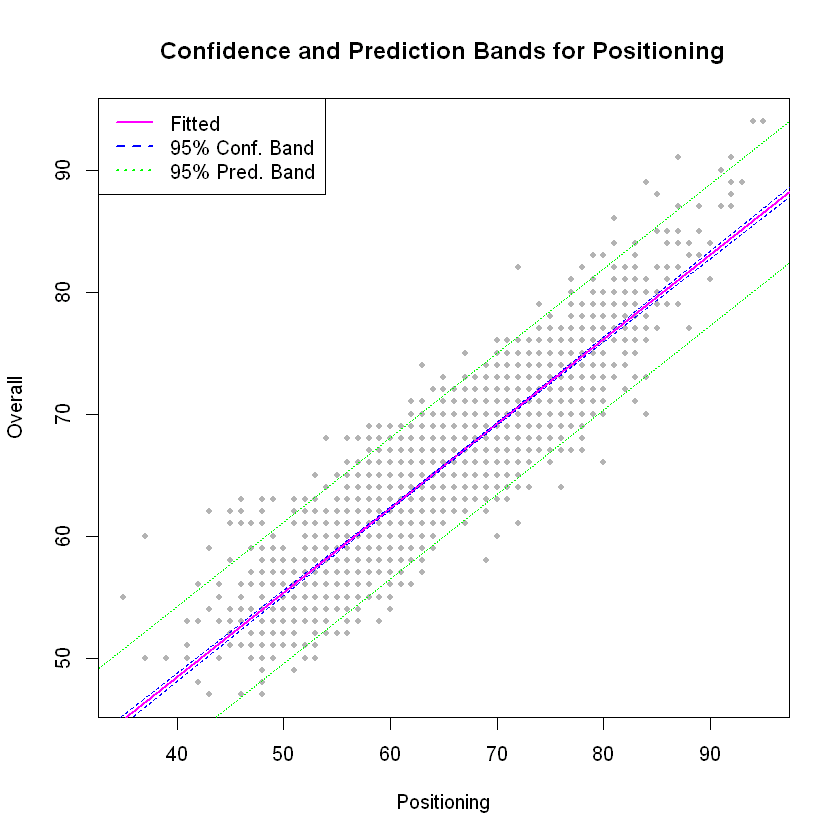

In [62]:
newdata_pos <- seq(1, 99, by = 0.05)

conf_interval <- predict(
  modelo_e1,
  newdata = data.frame(Positioning = newdata_pos),
  interval = "confidence", level = 0.95
)

pred_interval <- predict(
  modelo_e1,
  newdata = data.frame(Positioning = newdata_pos),
  interval = "prediction", level = 0.95
)

# Plot
plot(Positioning, Overall, pch = 20, col = "grey70",
     main = "Confidence and Prediction Bands for Positioning",
     xlab = "Positioning", ylab = "Overall")
lines(newdata_pos, conf_interval[, 1], col = "magenta", lwd = 2)   # Fitted line
lines(newdata_pos, conf_interval[, 2], col = "blue",    lty = 2)   # CI lower
lines(newdata_pos, conf_interval[, 3], col = "blue",    lty = 2)   # CI upper
lines(newdata_pos, pred_interval[, 2], col = "green",   lty = 3)   # PI lower
lines(newdata_pos, pred_interval[, 3], col = "green",   lty = 3)   # PI upper
legend("topleft",
       legend = c("Fitted", "95% Conf. Band", "95% Pred. Band"),
       col    = c("magenta", "blue", "green"),
       lty    = c(1, 2, 3), lwd = 2)

### 9.3 Effect of Changing Height from Category 3 (Alto) to Category 2 (Médio)

In Model E, the reference category for `Height` is **Alto (High)**. The dummy coefficients estimate the expected change in `Overall` when moving from `Alto` to another category, holding all else constant.

From the Model E output:
- `HeightBaixo` = +0.165 (moving from Alto to Baixo → +0.165 in Overall)
- `HeightMedio` = +0.188 (moving from Alto to Médio → +0.188 in Overall)

**Specific question:** What is the effect of changing from **Alto (category 3) to Médio (category 2)**?

The answer is directly given by the `HeightMedio` coefficient: **+0.188 points** (with a 95% CI computed below).

> Note: Neither `HeightBaixo` nor `HeightMedio` is statistically significant in Model E (p > 0.05). This confirms that height does not have a practically meaningful effect on the `Overall` rating of forward players, all else equal.

In [63]:
# 95% Confidence Interval for the HeightMedio coefficient
# (= effect of changing from Alto to Medio)
cat("Effect of changing Height from Alto to Medio:\n")
confint(modelo_e, "HeightMedio", level = 0.95)

Effect of changing Height from Alto to Medio:


,2.5 %,97.5 %
HeightMedio,-0.08531621,0.4605585


### 9.4 Effect of Increasing `Positioning` by 2 Standard Deviations

Standardised regression coefficients express effect sizes in standard deviation units. A coefficient of β* means: *the response increases by β* standard deviations when the predictor increases by 1 SD*.

For an increase of **2 SDs** in `Positioning`:

$$\Delta \hat{\text{Overall}} = 2 \times \beta^*_{\text{Positioning}} \times SD_{\text{Overall}}$$

Or equivalently, using the standardised coefficient from Model E: $2 \times 0.708 = 1.42$ standard deviations of `Overall`.

In [64]:
# Numeric version of nfifa19_forward_pos for lm.beta
modelo_e_num <- lm(
  Overall ~ Age + Height + Weight + PreferredFoot +
    Aggression + Positioning + Vision + Penalties,
  data = nfifa19_corr
)

std_betas <- lm.beta(modelo_e_num)
cat("Standardised beta coefficients for Mode E:\n")
print(round(std_betas, 4))

beta_positioning <- std_betas["Positioning"]
cat("\nEffect of 2 SD increase in Positioning:",
    round(2 * beta_positioning, 4), "SD units of Overall\n")
cat("In raw Overall units:",
    round(2 * beta_positioning * sd(Overall), 3), "\n")

Standardised beta coefficients for Mode E:
          Age        Height        Weight PreferredFoot    Aggression 
      -0.0304       -0.0086        0.0409       -0.0217        0.0733 
  Positioning        Vision     Penalties 
       0.7081        0.1908        0.1017 

Effect of 2 SD increase in Positioning: 1.4163 SD units of Overall
In raw Overall units: 9.996 


**Interpretation:** An increase of 2 standard deviations in `Positioning` is associated with an increase of **1.42 standard deviations** in `Overall` (approximately **10 points**), holding all other predictors constant. This confirms `Positioning` as the single most important predictor of forward player quality.

### 9.5 Interaction Between `Positioning` and `Height` (Model E2)

We test whether the **slope of `Positioning`** differs across the three height categories. This is an interaction effect: does being tall vs. short vs. medium affect *how much* positioning skill contributes to overall performance?

The interaction model (Model E2) adds terms `HeightBaixo:Positioning` and `HeightMedio:Positioning`.

In [65]:
modelo_e2 <- lm(
  Overall ~ Age + Height + Weight + PreferredFoot +
    Aggression + Positioning + Vision + Penalties + Height * Positioning,
  data = nfifa19_forward_pos
)
summary(modelo_e2)


Call:
lm(formula = Overall ~ Age + Height + Weight + PreferredFoot + 
    Aggression + Positioning + Vision + Penalties + Height * 
    Positioning, data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.9149 -1.6828 -0.0429  1.6605 11.2622 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             13.588841   0.947416  14.343  < 2e-16 ***
Age                     -0.045859   0.013683  -3.352 0.000815 ***
HeightBaixo              1.429519   0.930239   1.537 0.124480    
HeightMedio              0.724115   0.867669   0.835 0.404045    
Weight                   0.044932   0.009353   4.804 1.64e-06 ***
PreferredFootRight      -0.436442   0.142526  -3.062 0.002219 ** 
Aggression               0.032589   0.003913   8.329  < 2e-16 ***
Positioning              0.548733   0.011293  48.589  < 2e-16 ***
Vision                   0.136837   0.006758  20.248  < 2e-16 ***
Penalties                0.082467   0.007161  11.516 

**Results:**
- `HeightBaixo:Positioning` = -0.019, p = 0.169 → **not significant**
- `HeightMedio:Positioning` = -0.008, p = 0.537 → **not significant**

✅ **There is no statistically significant interaction between `Height` and `Positioning`.**

**Interpretation of the interaction terms (ignoring the inexistence of statistical significance):**
- **All forward players**:  the player’s `Overall` rating increases on average by 0.521 units (0.548733 - 0.019246 - 0.008020) for a 1-unit increase in the `Positioning` score, holding all other variables constant.
- **Short players (Baixo):** the `Overall` rating of a short player is on average 1.41 units higher (1.429519 - 0.019246) than that of a tall player, holding all other variables constant.
- **Medium players (Médio):** the `Overall` rating of a medium-height player is on average 0.716 units higher (0.724115 - 0.008020) than that of a tall player, holding all other variables constant.

The near-zero interaction coefficients confirm that the relationship between `Positioning` and `Overall` is essentially **uniform across height categories** — a reassuring finding.

---
## 10. Conclusions

This analysis built and validated a multiple linear regression model to explain the `Overall` rating of FIFA 2019 forward players from their physical and mentality characteristics.

### Key Findings

1. **`Positioning` is the dominant predictor** (standardised β = 0.708), accounting for the vast majority of the model's explanatory power. This is highly consistent with domain knowledge — scoring goals and positioning oneself to receive passes is the core job of a forward.

2. **`Vision`** (β = 0.191) and **`Penalties`** (β = 0.102) are the next most important mentality variables.

3. **`Composure`** was removed due to multicollinearity with `Positioning` (r = 0.80), not because it is unimportant — it simply overlaps too much with `Positioning` to reliably separate their effects.

4. **Physical characteristics** (`Height`, `Interceptions`) contributed little and were removed. `Age`, `Weight`, `Aggression`, and `PreferredFoot` remain in the model but with small effect sizes.

5. The model satisfies all key linear regression assumptions — normality of residuals, homoscedasticity, and no influential observations — making it a **reliable and interpretable** model.

6. **No significant interaction** was found between `Positioning` and `Height`, confirming that the effect of positioning skill is uniform across player heights.

In [66]:
detach(nfifa19_forward_pos)

cat("=== FINAL MODEL SUMMARY (Model 4) ===\n")
summary(modelo4)

cat("\n=== STANDARDISED COEFFICIENTS ===\n")
lm.beta(modelo4)

=== FINAL MODEL SUMMARY (Model 4) ===



Call:
lm(formula = Overall ~ Age + Weight + PreferredFoot + Aggression + 
    Positioning + Vision + Penalties, data = nfifa19_forward_pos)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.8636 -1.6757 -0.0328  1.6569 11.5326 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        14.726209   0.692689  21.259  < 2e-16 ***
Age                -0.045235   0.013649  -3.314 0.000931 ***
Weight              0.038215   0.007985   4.786 1.79e-06 ***
PreferredFootRight -0.432043   0.142494  -3.032 0.002453 ** 
Aggression          0.032379   0.003909   8.283  < 2e-16 ***
Positioning         0.539587   0.008247  65.430  < 2e-16 ***
Vision              0.137421   0.006733  20.409  < 2e-16 ***
Penalties           0.083396   0.007142  11.677  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.597 on 2659 degrees of freedom
Multiple R-squared:  0.8649,	Adjusted R-squared:  0.8646 
F-statistic:  243


=== STANDARDISED COEFFICIENTS ===


Warning message in var(if (is.vector(x) || is.factor(x)) x else as.double(x), na.rm = na.rm):
"NAs introduced by coercion"


Age             Weight PreferredFootRight         Aggression 
       -0.03015161         0.03715640                 NA         0.07291189 
       Positioning             Vision          Penalties 
        0.70766127         0.19125908         0.10219164